# Modell-Training 
**Teilnehmerin 4: ML Pipeline & Training**

Dieses Notebook trainiert und evaluiert 6 verschiedene Machine Learning Modelle zur Vorhersage von viralen TikTok-Videos.

## Verwendete Algorithmen:
1. **Logistic Regression** (Baseline)
2. **Decision Tree**
3. **Random Forest**
4. **Gradient Boosting**
5. **XGBoost**
6. **SVM**

## 1. Imports und Setup

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, roc_curve, f1_score,
    accuracy_score, precision_score, recall_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import xgboost as xgb

# Model Persistence
import joblib

# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Alle Imports erfolgreich!")
print(f"Pandas Version: {pd.__version__}")
print(f"XGBoost Version: {xgb.__version__}")

Alle Imports erfolgreich!
Pandas Version: 2.3.3
XGBoost Version: 2.0.3


## 2. Daten laden

In [ ]:
print("=" * 60)
print("DATEN LADEN")
print("=" * 60)

# Aktuelles Verzeichnis
current_dir = Path.cwd()
print(f"Aktuelles Verzeichnis: {current_dir}\n")

# Zum Projekt-Root navigieren
if current_dir.name == "notebook":
    project_root = current_dir.parent
else:
    project_root = current_dir

# Feature Matrix Pfad
data_file = project_root / "features" / "FINAL_FEATURE_MATRIX.csv"

if not data_file.exists():
    raise FileNotFoundError(
        f"Datei nicht gefunden: {data_file}\n"
        "Bitte führen Sie zuerst integrate_features.ipynb aus!"
    )

# Daten laden
df = pd.read_csv(data_file)

print(f"\nDatei geladen: {data_file.name}")
print(f" Daten-Shape: {df.shape}")
print(f"   • Videos: {len(df)}")
print(f"   • Spalten: {len(df.columns)}")

# Erste 3 Zeilen anzeigen
print("\nErste 3 Zeilen:")
display(df.head(3))

DATEN LADEN
Aktuelles Verzeichnis: /Users/jolanda/Desktop/Study/Project_Algorithmus/Viralitaetsanalyse-main/notebook


✅ Datei geladen: FINAL_FEATURE_MATRIX.csv
 Daten-Shape: (197, 38)
   • Videos: 197
   • Spalten: 38

Erste 3 Zeilen:


,group,is_viral_proxy,txt_title_has_mention,txt_title_has_question,txt_title_has_hashtag,bpm,rms_mean,rms_std,spectral_centroid_mean,spectral_centroid_std,...,video_dauer_sek,ist_person_prominent,ist_tier_sichtbar,avg_objekte_pro_frame,avg_gesichter_pro_frame,dominante_emotion,ist_text_eingeblendet,text_sentiment_compound,video_kategorie,is_viral
0,top,1,0,0,0,78.302557,0.018957,0.005904,929.528668,1097.230358,...,9.0,1,0,1.0,1.0,neutral,1,0.0000,Prank,1
1,top,1,0,0,0,139.674831,0.044484,0.053435,2763.921836,1675.872473,...,29.0,1,0,2.0,1.6,happy,1,-0.4767,Fitness,1
2,normal,0,0,0,1,132.512019,0.249890,0.122323,1703.203627,858.816616,...,20.0,1,0,4.4,2.2,sad,1,0.0000,Unboxing,0


## 3. Label-Verteilung prüfen

In [ ]:
# Prüfen ob is_viral vorhanden
if 'is_viral' not in df.columns:
    raise ValueError(
        "Spalte 'is_viral' nicht gefunden!\n"
        "Die Labels müssen in der Feature-Matrix vorhanden sein."
    )

print(" LABEL-VERTEILUNG:\n")

viral_count = int(df['is_viral'].sum())
normal_count = len(df) - viral_count
total = len(df)

print(f"  • Viral (1):  {viral_count:3d} ({viral_count/total*100:5.1f}%)")
print(f"  • Normal (0): {normal_count:3d} ({normal_count/total*100:5.1f}%)")
print(f"  • Gesamt:     {total:3d}")

if viral_count < 10 or normal_count < 10:
    print("\nWARNUNG: Sehr wenige Beispiele in einer Klasse!")
    print("   Das kann die Modell-Performance beeinträchtigen.")

 LABEL-VERTEILUNG:

  • Viral (1):  100 ( 50.8%)
  • Normal (0):  97 ( 49.2%)
  • Gesamt:     197


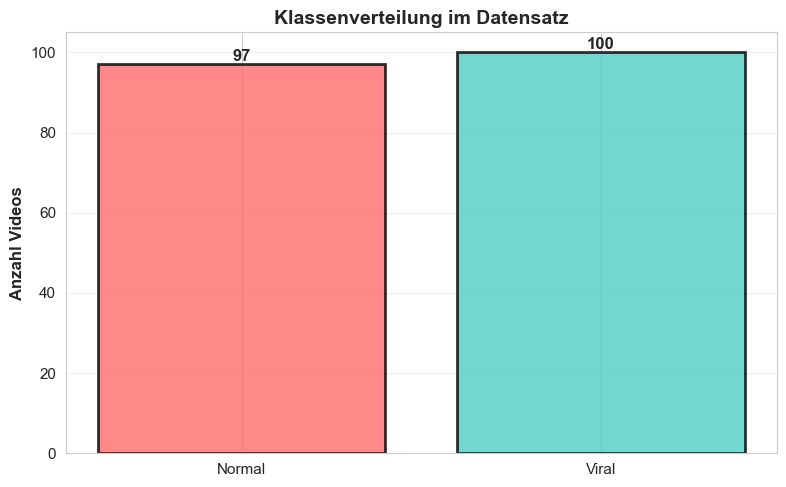

In [4]:
# Visualisierung der Klassenverteilung
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#ff6b6b', '#4ecdc4']
bars = ax.bar(['Normal', 'Viral'], [normal_count, viral_count], 
               color=colors, alpha=0.8, edgecolor='black', linewidth=2)

ax.set_ylabel('Anzahl Videos', fontsize=12, fontweight='bold')
ax.set_title('Klassenverteilung im Datensatz', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Feature-Vorbereitung

In [ ]:
print("=" * 60)
print(" FEATURE-VORBEREITUNG")
print("=" * 60)

# KRITISCH: Alle ID- und Label-Spalten ausschließen
exclude_patterns = ['video_id', 'is_viral', 'group', 'is_viral_proxy', 'original']

# Finde alle Spalten die ausgeschlossen werden sollen
exclude_cols = []
for col in df.columns:
    col_lower = str(col).lower()
    for pattern in exclude_patterns:
        if pattern in col_lower:
            exclude_cols.append(col)
            break

# Features extrahieren
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()
y = df['is_viral'].copy()

print(f"\n Features extrahiert:")
print(f"   • Ausgeschlossene Spalten: {len(exclude_cols)}")
for ex in exclude_cols:
    print(f"     - {ex}")
print(f"   • Feature-Anzahl: {len(feature_cols)}")
print(f"   • Label-Anzahl: {len(y)}")

# Erste 20 Features zur Kontrolle
print(f"\n Erste 20 Features:")
for i, col in enumerate(feature_cols[:20], 1):
    print(f"   {i:2d}. {col}")
if len(feature_cols) > 20:
    print(f"   ... und {len(feature_cols) - 20} weitere")

# Warnung bei zu vielen Features
if len(feature_cols) > 100:
    print(f"\n WARNUNG: {len(feature_cols)} Features - möglicherweise zu viele!")
    print("   Prüfen Sie ob video_id Spalten korrekt entfernt wurden.")
elif len(feature_cols) < 10:
    print(f"\n WARNUNG: {len(feature_cols)} Features - zu wenige!")
else:
    print(f"\n Feature-Anzahl im erwarteten Bereich!")

# Feature-Namen speichern
original_feature_names = feature_cols.copy()

 FEATURE-VORBEREITUNG

✅ Features extrahiert:
   • Ausgeschlossene Spalten: 3
     - group
     - is_viral_proxy
     - is_viral
   • Feature-Anzahl: 35
   • Label-Anzahl: 197

 Erste 20 Features:
    1. txt_title_has_mention
    2. txt_title_has_question
    3. txt_title_has_hashtag
    4. bpm
    5. rms_mean
    6. rms_std
    7. spectral_centroid_mean
    8. spectral_centroid_std
    9. spectral_bandwidth_mean
   10. spectral_bandwidth_std
   11. speech_ratio
   12. chroma_var_0
   13. chroma_var_1
   14. chroma_var_2
   15. chroma_var_3
   16. chroma_var_4
   17. chroma_var_5
   18. chroma_var_6
   19. chroma_var_7
   20. chroma_var_8
   ... und 15 weitere

✅ Feature-Anzahl im erwarteten Bereich!


### 4.1 Kategorische Features behandeln (One-Hot Encoding)

**Algorithmus:** Dummy Variable Encoding
- Konvertiert kategorische Variablen in numerische
- `drop_first=True` vermeidet Multikollinearität

In [ ]:
# Nicht-numerische Spalten finden
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()

if non_numeric:
    print(f"\n One-Hot-Encoding für {len(non_numeric)} kategorische Features:\n")
    for col in non_numeric:
        unique_vals = X[col].nunique()
        print(f"   • {col}: {unique_vals} eindeutige Werte")
        if unique_vals <= 5:
            print(f"     Werte: {X[col].unique()[:5]}")
    
    # One-Hot Encoding anwenden
    X = pd.get_dummies(X, columns=non_numeric, drop_first=True)
    
    print(f"\n Encoding abgeschlossen")
    print(f"   • Neue Feature-Anzahl: {len(X.columns)}")
else:
    print("\n Alle Features sind bereits numerisch")

# Finale Feature-Namen
final_feature_names = X.columns.tolist()

print(f"\n FINALE FEATURES ({len(final_feature_names)}):")
for i, col in enumerate(final_feature_names[:15], 1):
    print(f"   {i:2d}. {col}")
if len(final_feature_names) > 15:
    print(f"   ... und {len(final_feature_names) - 15} weitere")


 One-Hot-Encoding für 2 kategorische Features:

   • dominante_emotion: 6 eindeutige Werte
   • video_kategorie: 12 eindeutige Werte

✅ Encoding abgeschlossen
   • Neue Feature-Anzahl: 49

 FINALE FEATURES (49):
    1. txt_title_has_mention
    2. txt_title_has_question
    3. txt_title_has_hashtag
    4. bpm
    5. rms_mean
    6. rms_std
    7. spectral_centroid_mean
    8. spectral_centroid_std
    9. spectral_bandwidth_mean
   10. spectral_bandwidth_std
   11. speech_ratio
   12. chroma_var_0
   13. chroma_var_1
   14. chroma_var_2
   15. chroma_var_3
   ... und 34 weitere


## 5. Train-Test Split

**Algorithmus:** Stratified Sampling
- 80% Training, 20% Test
- Erhält die Klassenverteilung in beiden Sets
- `random_state=42` für Reproduzierbarkeit

In [7]:
print("\n" + "=" * 60)
print(" DATEN-SPLIT")
print("=" * 60)

# Split durchführen
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% Training, 20% Test
    random_state=42,    # Reproduzierbarkeit
    stratify=y          # Gleiche Klassenverteilung
)

print(f"\n✅ Split abgeschlossen:")
print(f"   • Training Set: {len(X_train)} Samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   • Test Set:     {len(X_test)} Samples ({len(X_test)/len(X)*100:.1f}%)")

# Verteilung prüfen
train_viral = y_train.sum()
test_viral = y_test.sum()

print(f"\n Training Set Verteilung:")
print(f"   • Viral:  {train_viral} ({train_viral/len(y_train)*100:.1f}%)")
print(f"   • Normal: {len(y_train)-train_viral} ({(len(y_train)-train_viral)/len(y_train)*100:.1f}%)")

print(f"\n Test Set Verteilung:")
print(f"   • Viral:  {test_viral} ({test_viral/len(y_test)*100:.1f}%)")
print(f"   • Normal: {len(y_test)-test_viral} ({(len(y_test)-test_viral)/len(y_test)*100:.1f}%)")


 DATEN-SPLIT

✅ Split abgeschlossen:
   • Training Set: 157 Samples (79.7%)
   • Test Set:     40 Samples (20.3%)

 Training Set Verteilung:
   • Viral:  80 (51.0%)
   • Normal: 77 (49.0%)

 Test Set Verteilung:
   • Viral:  20 (50.0%)
   • Normal: 20 (50.0%)


## 6. Feature-Skalierung (StandardScaler)

**Algorithmus:** Z-Score Normalization

**Formel:** `x_scaled = (x - μ) / σ`
- μ = Mittelwert
- σ = Standardabweichung
- **Ergebnis:** Mittelwert=0, Standardabweichung=1

**Wichtig:** Verhindert Feature Dominanz (z.B. "Likes" mit Werten 1M vs "duration" mit Werten 15)

In [ ]:
print("\n" + "=" * 60)
print(" FEATURE-SKALIERUNG")
print("=" * 60)

# Scaler erstellen und anwenden
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n StandardScaler angewendet")

# Vergleich vor/nach Skalierung
print("\n Beispiel - Vor Skalierung:")
print(f"   Mean: {X_train.iloc[:, 0].mean():.2f}")
print(f"   Std:  {X_train.iloc[:, 0].std():.2f}")

print("\n Beispiel - Nach Skalierung:")
print(f"   Mean: {X_train_scaled[:, 0].mean():.5f}")
print(f"   Std:  {X_train_scaled[:, 0].std():.5f}")


 FEATURE-SKALIERUNG

✅ StandardScaler angewendet

 Beispiel - Vor Skalierung:
   Mean: 0.32
   Std:  0.47

 Beispiel - Nach Skalierung:
   Mean: 0.00000
   Std:  1.00000


## 7. Baseline-Modell: Logistische Regression

**Algorithmus:** Logistic Regression
- **Formel:** P(y=1|x) = 1 / (1 + e^(-(β₀ + β₁x₁ + ... + βₙxₙ)))
- **Optimierung:** LBFGS (Limited-memory BFGS)
- **Vorteile:** Schnell, interpretierbar, gute Baseline

In [ ]:
print("\n" + "=" * 60)
print("BASELINE-MODELL: Logistische Regression")
print("=" * 60)

# Modell erstellen und trainieren
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

# Vorhersagen
y_pred_baseline = baseline_model.predict(X_test_scaled)
y_pred_proba_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

# Metriken
f1_baseline = f1_score(y_test, y_pred_baseline)
auc_baseline = roc_auc_score(y_test, y_pred_proba_baseline)
acc_baseline = accuracy_score(y_test, y_pred_baseline)

print(f"\n Training abgeschlossen")
print(f"\n Baseline-Performance:")
print(f"    Accuracy:  {acc_baseline:.3f}")
print(f"    F1-Score:  {f1_baseline:.3f}")
print(f"    AUC-ROC:   {auc_baseline:.3f}")

# Speichern für Vergleich
models = {'Logistic Regression': baseline_model}
results = {
    'Logistic Regression': {
        'accuracy': acc_baseline,
        'f1_score': f1_baseline,
        'auc_roc': auc_baseline,
        'y_pred': y_pred_baseline,
        'y_pred_proba': y_pred_proba_baseline
    }
}


BASELINE-MODELL: Logistische Regression

✅ Training abgeschlossen

 Baseline-Performance:
   • Accuracy:  0.425
   • F1-Score:  0.378
   • AUC-ROC:   0.470


## 8. Modell-Vergleich: Alle 6 Algorithmen trainieren

Wir trainieren folgende Modelle:
1.  Logistic Regression (bereits trainiert)
2.  Decision Tree
3.  Random Forest
4.  Gradient Boosting
5.  XGBoost
6.  SVM

In [ ]:
print("\n" + "=" * 60)
print(" MODELL-VERGLEICH")
print("=" * 60)

# Modelle definieren
models_to_train = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, max_depth=5, use_label_encoder=False, eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42, kernel='rbf')
}

print(f"\nTrainiere {len(models_to_train)} Modelle...\n")

# Trainingsschleife
for name, model in models_to_train.items():
    print(f" {name}:")
    
    try:
        # Training
        model.fit(X_train_scaled, y_train)
        
        # Vorhersagen
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        
        # Metriken
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        # Speichern
        models[name] = model
        results[name] = {
            'accuracy': acc,
            'f1_score': f1,
            'auc_roc': auc,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }
        
        print(f" Acc: {acc:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")
        
    except Exception as e:
        print(f"   X Fehler: {e}")

print("\nAlle Modelle trainiert!")


 MODELL-VERGLEICH

Trainiere 5 Modelle...

 Decision Tree:
 ✅ Acc: 0.475 | F1: 0.462 | AUC: 0.475
 Random Forest:
 ✅ Acc: 0.575 | F1: 0.564 | AUC: 0.630
 Gradient Boosting:
 ✅ Acc: 0.450 | F1: 0.476 | AUC: 0.467
 XGBoost:
 ✅ Acc: 0.625 | F1: 0.634 | AUC: 0.677
 SVM:
 ✅ Acc: 0.475 | F1: 0.462 | AUC: 0.481

✅ Alle Modelle trainiert!


## 9. Modell-Ranking

In [11]:
print("\n" + "=" * 60)
print(" MODELL-RANKING")
print("=" * 60)

# Nach F1-Score sortieren
sorted_results = sorted(
    results.items(),
    key=lambda x: x[1]['f1_score'],
    reverse=True
)

print("\n Sortiert nach F1-Score:\n")
print(f"{'Rang':<6} {'Modell':<25} {'Accuracy':<10} {'F1-Score':<10} {'AUC-ROC':<10}")
print("-" * 65)

for i, (name, metrics) in enumerate(sorted_results, 1):
    print(f"{i:<6} {name:<25} {metrics['accuracy']:<10.3f} {metrics['f1_score']:<10.3f} {metrics['auc_roc']:<10.3f}")

# Bestes Modell identifizieren
best_model_name = sorted_results[0][0]
best_model = models[best_model_name]
best_results = results[best_model_name]

print(f"\n BESTES MODELL: {best_model_name}")
print(f"   • Accuracy:  {best_results['accuracy']:.3f}")
print(f"   • F1-Score:  {best_results['f1_score']:.3f}")
print(f"   • AUC-ROC:   {best_results['auc_roc']:.3f}")


 MODELL-RANKING

 Sortiert nach F1-Score:

Rang   Modell                    Accuracy   F1-Score   AUC-ROC   
-----------------------------------------------------------------
1      XGBoost                   0.625      0.634      0.677     
2      Random Forest             0.575      0.564      0.630     
3      Gradient Boosting         0.450      0.476      0.467     
4      Decision Tree             0.475      0.462      0.475     
5      SVM                       0.475      0.462      0.481     
6      Logistic Regression       0.425      0.378      0.470     

 BESTES MODELL: XGBoost
   • Accuracy:  0.625
   • F1-Score:  0.634
   • AUC-ROC:   0.677


## 10. Visualisierung: Modell-Vergleich

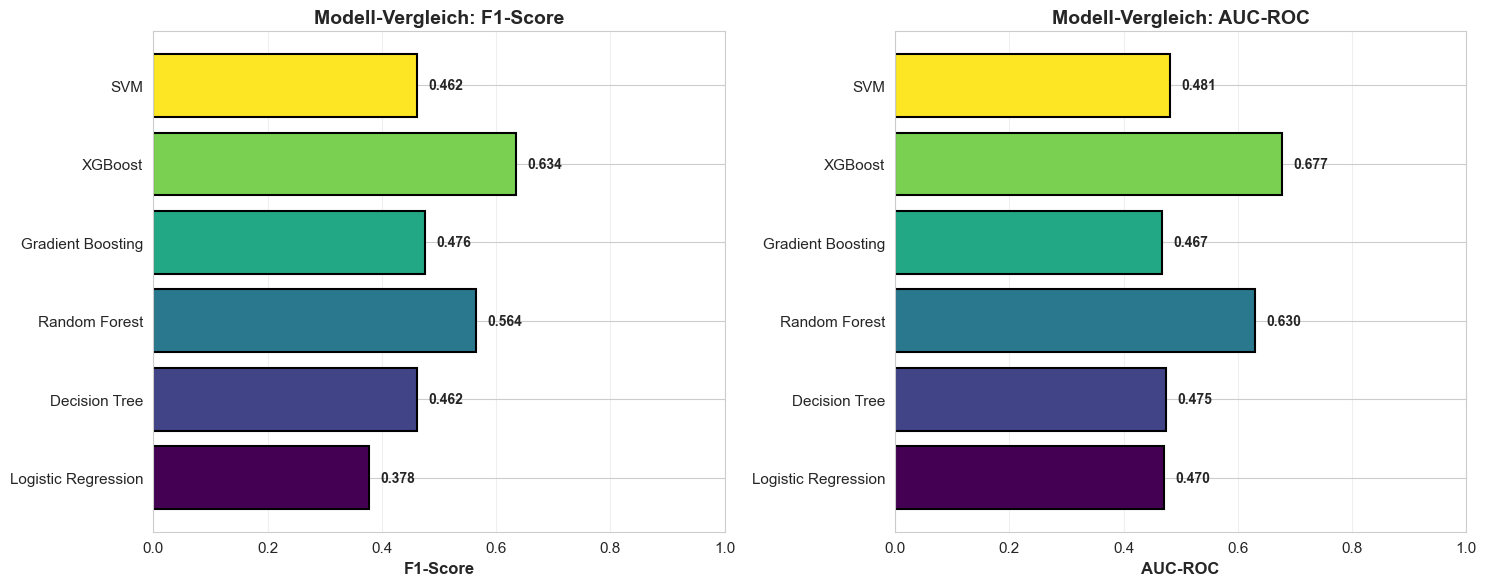

 Visualisierung gespeichert: results/model_comparison.png


In [12]:
# Daten für Plot vorbereiten
model_names = list(results.keys())
f1_scores = [results[m]['f1_score'] for m in model_names]
auc_scores = [results[m]['auc_roc'] for m in model_names]

# Plot erstellen
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(model_names)))

# F1-Score
bars1 = ax1.barh(model_names, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
ax1.set_title('Modell-Vergleich: F1-Score', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

for i, (bar, score) in enumerate(zip(bars1, f1_scores)):
    ax1.text(score + 0.02, i, f'{score:.3f}', va='center', fontsize=10, fontweight='bold')

# AUC-ROC
bars2 = ax2.barh(model_names, auc_scores, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('AUC-ROC', fontsize=12, fontweight='bold')
ax2.set_title('Modell-Vergleich: AUC-ROC', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)

for i, (bar, score) in enumerate(zip(bars2, auc_scores)):
    ax2.text(score + 0.02, i, f'{score:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()

# Speichern
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)
plt.savefig(results_dir / 'model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Visualisierung gespeichert: results/model_comparison.png")

## 11. Detaillierte Evaluierung des besten Modells

In [13]:
print("\n" + "=" * 60)
print(f" DETAILLIERTE EVALUIERUNG: {best_model_name}")
print("=" * 60)

y_pred_best = best_results['y_pred']
y_pred_proba_best = best_results['y_pred_proba']


 DETAILLIERTE EVALUIERUNG: XGBoost


### 11.1 Classification Report

In [14]:
print("\n CLASSIFICATION REPORT:\n")
print(classification_report(
    y_test, y_pred_best,
    target_names=['Normal', 'Viral'],
    digits=3
))


 CLASSIFICATION REPORT:

              precision    recall  f1-score   support

      Normal      0.632     0.600     0.615        20
       Viral      0.619     0.650     0.634        20

    accuracy                          0.625        40
   macro avg      0.625     0.625     0.625        40
weighted avg      0.625     0.625     0.625        40



### 11.2 Confusion Matrix


 CONFUSION MATRIX:

                 Predicted
               Normal  Viral
Actual Normal     12      8
       Viral       7     13


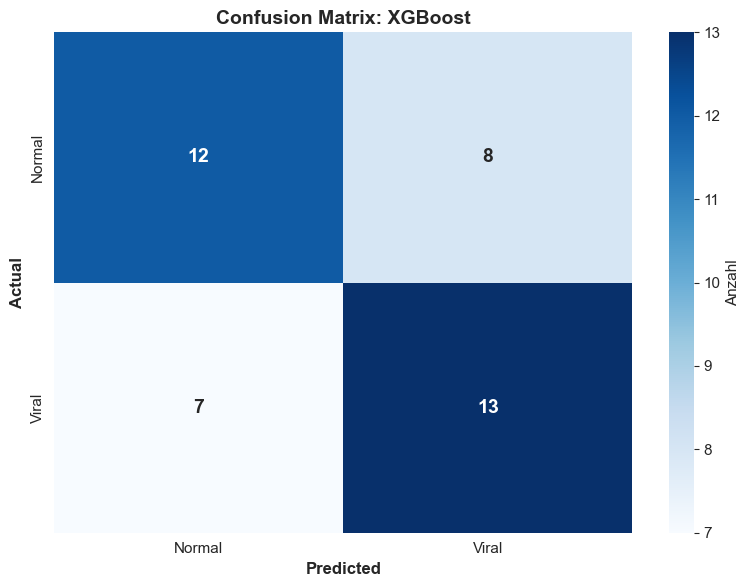


✓ Gespeichert: results/confusion_matrix.png


In [15]:
cm = confusion_matrix(y_test, y_pred_best)

print("\n CONFUSION MATRIX:")
print("\n                 Predicted")
print("               Normal  Viral")
print(f"Actual Normal    {cm[0][0]:3d}    {cm[0][1]:3d}")
print(f"       Viral     {cm[1][0]:3d}    {cm[1][1]:3d}")

# Visualisierung
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Viral'],
            yticklabels=['Normal', 'Viral'],
            cbar_kws={'label': 'Anzahl'},
            ax=ax, annot_kws={"size": 14, "weight": "bold"})
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix: {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Gespeichert: results/confusion_matrix.png")

### 11.3 Cross-Validation (5-Fold)

**Algorithmus:** K-Fold Cross-Validation
- Teilt Trainingsdaten in 5 gleiche Teile
- Trainiert 5 Modelle mit unterschiedlichen Train/Test-Kombinationen
- Gibt robuste Einschätzung der Performance


 CROSS-VALIDATION (5-Fold):

F1-Scores pro Fold: [0.47058824 0.54545455 0.38461538 0.52941176 0.59459459]

Durchschnitt: 0.505
Standardabweichung: 0.072
Konfidenzintervall: 0.505 ± 0.072


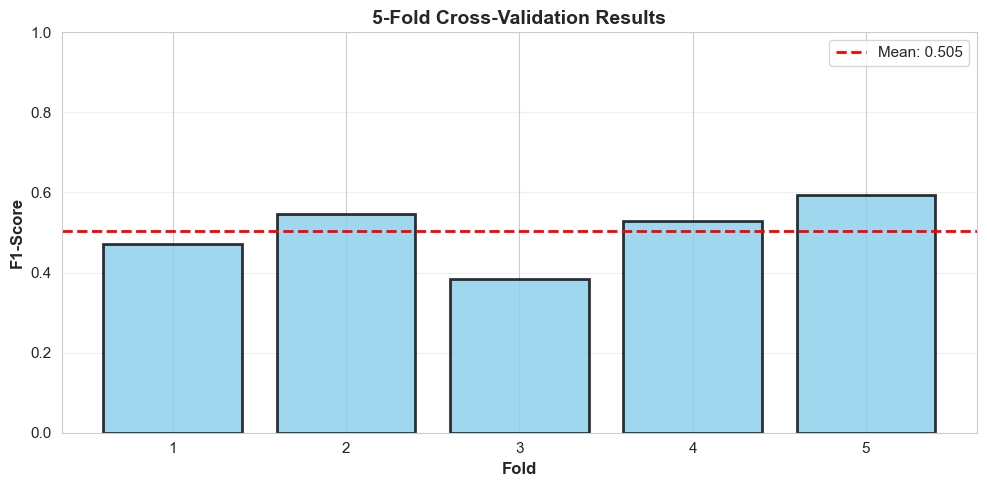


✓ Gespeichert: results/cross_validation.png


In [16]:
print("\n CROSS-VALIDATION (5-Fold):\n")

cv_scores = cross_val_score(
    best_model, 
    X_train_scaled, 
    y_train,
    cv=5,
    scoring='f1'
)

print(f"F1-Scores pro Fold: {cv_scores}")
print(f"\nDurchschnitt: {cv_scores.mean():.3f}")
print(f"Standardabweichung: {cv_scores.std():.3f}")
print(f"Konfidenzintervall: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 6), cv_scores, alpha=0.8, color='skyblue', edgecolor='black', linewidth=2)
ax.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.3f}')
ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / 'cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Gespeichert: results/cross_validation.png")

## 12. Feature Importance Analyse 

**Algorithmus:** Gini Importance (für Random Forest/XGBoost)
- Berechnet wie viel jedes Feature zur Reduktion der Unreinheit beiträgt
- Wichtigere Features = höhere Werte

In [17]:
print("\n" + "=" * 60)
print(" FEATURE IMPORTANCE")
print("=" * 60)

# Prüfen ob das Modell Feature Importance unterstützt
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    print("\nAchtung: Dieses Modell unterstützt keine Feature Importance Analyse")
    importances = None

if importances is not None:
    # DataFrame erstellen
    feature_importance_df = pd.DataFrame({
        'feature': final_feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print("\n TOP 20 WICHTIGSTE FEATURES:\n")
    for i, row in feature_importance_df.head(20).iterrows():
        print(f"  {i+1:2d}. {row['feature']:40s} {row['importance']:.4f}")
    
    # Speichern
    feature_importance_df.to_csv(results_dir / 'feature_importance.csv', index=False)
    print(f"\n Gespeichert: results/feature_importance.csv")


 FEATURE IMPORTANCE

 TOP 20 WICHTIGSTE FEATURES:

   3. txt_title_has_hashtag                    0.1850
  39. video_kategorie_Comedy                   0.0564
   1. txt_title_has_mention                    0.0412
  18. chroma_var_6                             0.0406
  24. schnitt_frequenz                         0.0363
  10. spectral_bandwidth_std                   0.0363
  13. chroma_var_1                             0.0351
  25. durchschnittliche_bewegung               0.0343
   7. spectral_centroid_mean                   0.0313
  26. anzahl_frames                            0.0298
  12. chroma_var_0                             0.0296
  23. chroma_var_11                            0.0295
   5. rms_mean                                 0.0294
  20. chroma_var_8                             0.0287
  11. speech_ratio                             0.0281
  33. text_sentiment_compound                  0.0278
  30. avg_objekte_pro_frame                    0.0272
  22. chroma_var_10           

### 12.1 Visualisierung: Top 20 Features

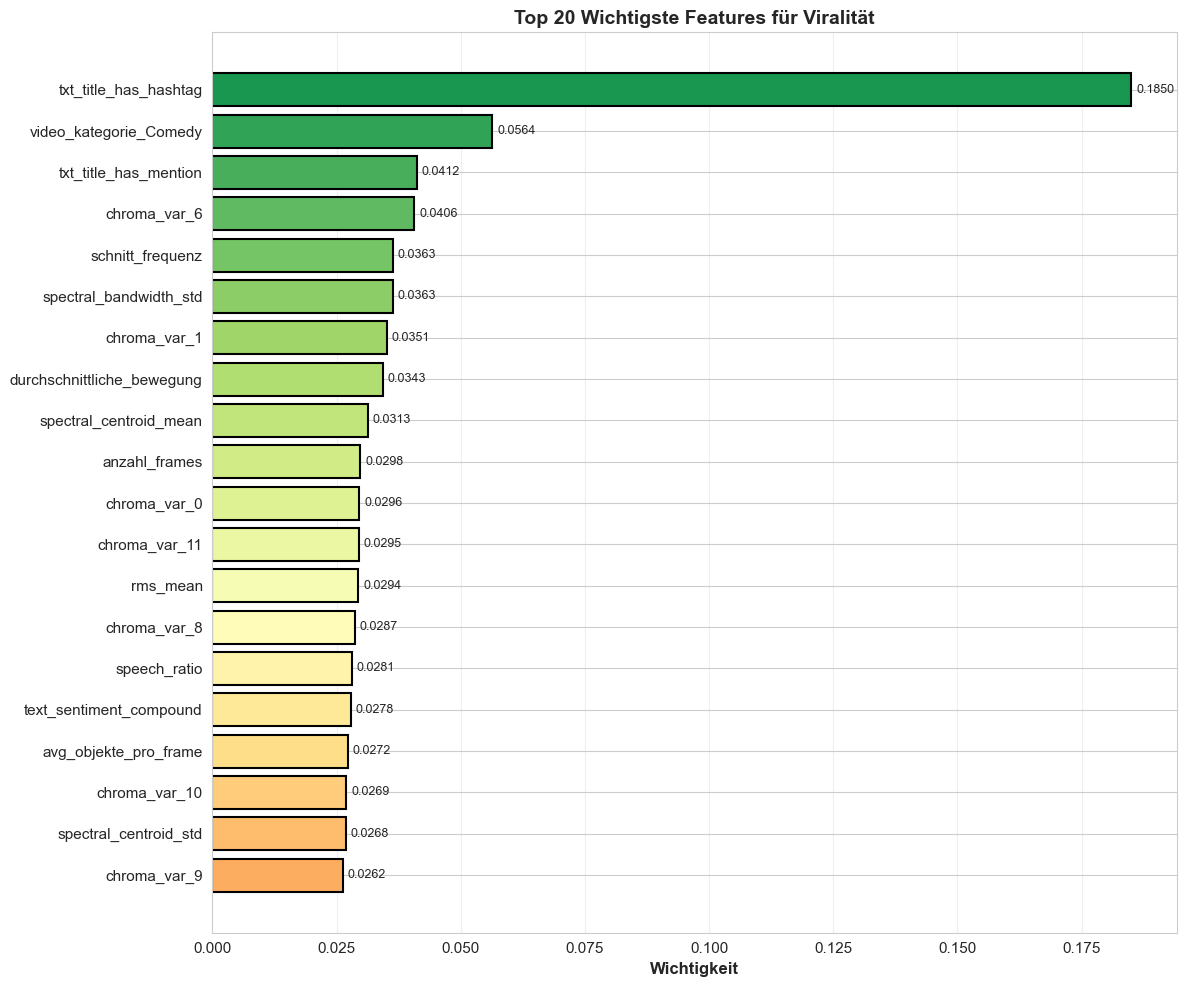

Gespeichert: results/feature_importance_top20.png


In [18]:
if importances is not None:
    top20 = feature_importance_df.head(20).sort_values('importance')
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top20)))
    bars = ax.barh(range(len(top20)), top20['importance'], color=colors, edgecolor='black', linewidth=1.5)
    
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20['feature'])
    ax.set_xlabel('Wichtigkeit', fontsize=12, fontweight='bold')
    ax.set_title('Top 20 Wichtigste Features für Viralität', 
                 fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Werte auf Balken
    for i, (bar, val) in enumerate(zip(bars, top20['importance'])):
        ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(results_dir / 'feature_importance_top20.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Gespeichert: results/feature_importance_top20.png")

### 12.2 Feature-Kategorien Analyse

In [19]:
if importances is not None:
    # Kategorien zuordnen
    def categorize_feature(feature_name):
        feature_lower = feature_name.lower()
        
        # Audio-Features
        if any(keyword in feature_lower for keyword in 
               ['tempo', 'bpm', 'energy', 'mfcc', 'spectral', 'chroma', 
                'rms', 'zero_crossing', 'audio', 'sound', 'beat', 'speech']):
            return 'Audio'
        
        # Video-Features
        if any(keyword in feature_lower for keyword in 
               ['frame', 'scene', 'motion', 'optical', 'face', 'object', 
                'color', 'brightness', 'contrast', 'visual', 'cut', 'schnitt', 
                'bewegung', 'person', 'tier', 'gesicht', 'dauer', 'emotion', 
                'kategorie', 'sentiment', 'text_eingeblendet']):
            return 'Video'
        
        # Metadaten
        return 'Metadaten'
    
    feature_importance_df['category'] = feature_importance_df['feature'].apply(categorize_feature)
    
    # Summe pro Kategorie
    category_importance = feature_importance_df.groupby('category')['importance'].sum().sort_values(ascending=False)
    
    print("\n Feature Importance nach Kategorie:\n")
    for cat, imp in category_importance.items():
        count = len(feature_importance_df[feature_importance_df['category'] == cat])
        pct = imp / category_importance.sum() * 100
        print(f"  • {cat:15s} {imp:.4f} ({pct:.1f}%) - {count} Features")


 Feature Importance nach Kategorie:

  • Audio           0.5333 (53.3%) - 20 Features
  • Video           0.2406 (24.1%) - 26 Features
  • Metadaten       0.2261 (22.6%) - 3 Features


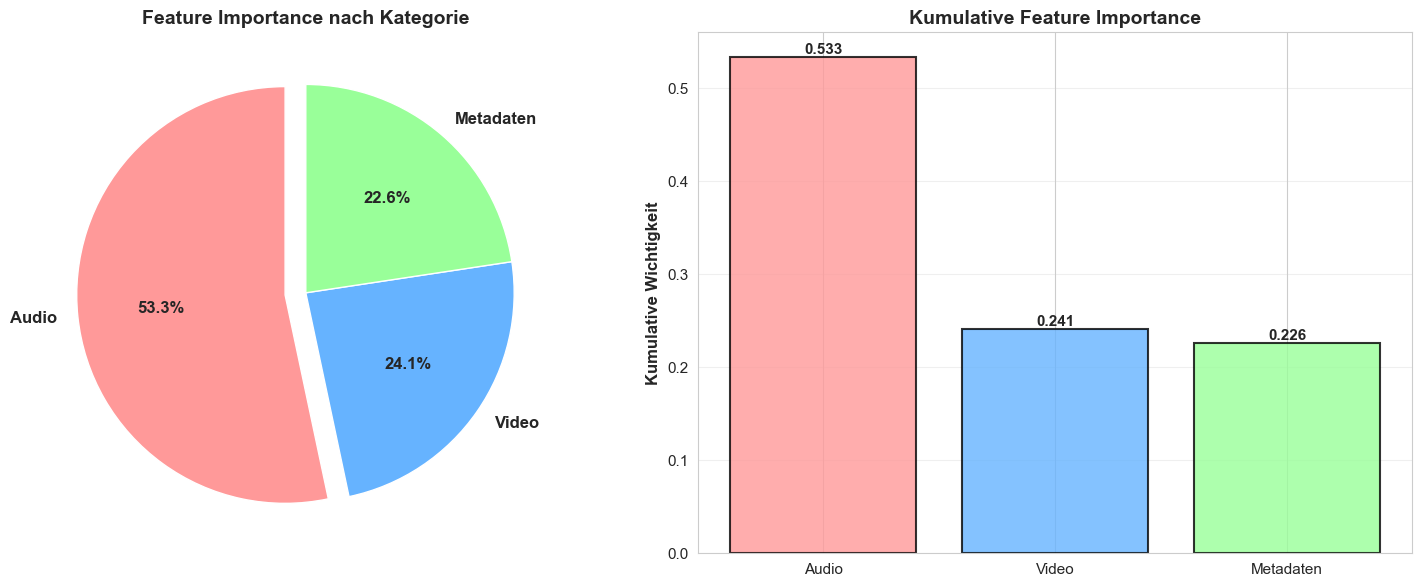

✓ Gespeichert: results/feature_categories.png


In [20]:
if importances is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Pie Chart
    colors_pie = ['#ff9999', '#66b3ff', '#99ff99']
    explode = (0.1, 0, 0)
    
    wedges, texts, autotexts = ax1.pie(
        category_importance, 
        labels=category_importance.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors_pie,
        explode=explode,
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )
    
    ax1.set_title('Feature Importance nach Kategorie', 
                  fontsize=14, fontweight='bold')
    
    # Bar Chart
    bars = ax2.bar(category_importance.index, category_importance.values, 
                   color=colors_pie, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('Kumulative Wichtigkeit', fontsize=12, fontweight='bold')
    ax2.set_title('Kumulative Feature Importance', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(results_dir / 'feature_categories.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Gespeichert: results/feature_categories.png")

## 13. ROC Curve Visualisierung


 ROC CURVE


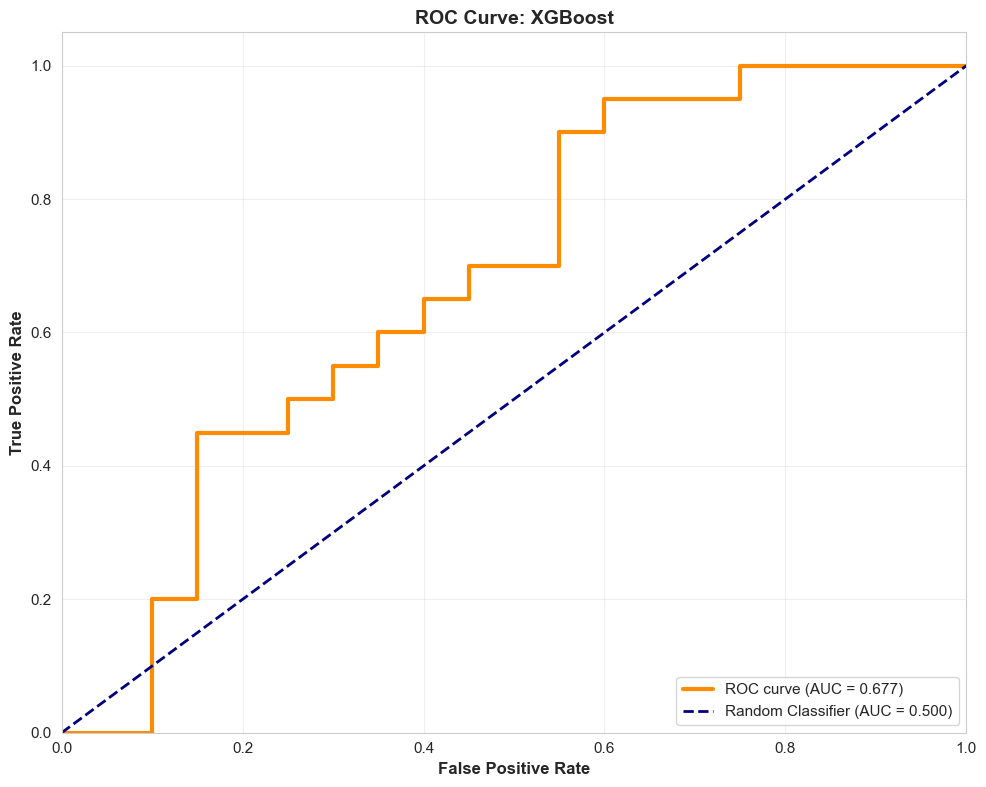


 AUC-ROC Score: 0.677
 Gespeichert: results/roc_curve.png


In [21]:
print("\n" + "=" * 60)
print(" ROC CURVE")
print("=" * 60)

# ROC Curve für bestes Modell
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
roc_auc = best_results['auc_roc']

fig, ax = plt.subplots(figsize=(10, 8))

# ROC Curve plotten
ax.plot(fpr, tpr, color='darkorange', lw=3, 
        label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
        label='Random Classifier (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title(f'ROC Curve: {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n AUC-ROC Score: {roc_auc:.3f}")
print(" Gespeichert: results/roc_curve.png")

## 14. Modelle und Scaler speichern

In [22]:
print("\n" + "=" * 60)
print(" MODELLE SPEICHERN")
print("=" * 60)

# Bestes Modell speichern
model_file = results_dir / f"best_model_{best_model_name.replace(' ', '_')}.pkl"
joblib.dump(best_model, model_file)
print(f"\n Bestes Modell gespeichert: {model_file.name}")

# Scaler speichern
scaler_file = results_dir / "scaler.pkl"
joblib.dump(scaler, scaler_file)
print(f" Scaler gespeichert: {scaler_file.name}")

# Feature-Namen speichern
feature_names_file = results_dir / "feature_names.json"
with open(feature_names_file, 'w') as f:
    json.dump(final_feature_names, f, indent=2)
print(f" Feature-Namen gespeichert: {feature_names_file.name}")


 MODELLE SPEICHERN

 Bestes Modell gespeichert: best_model_XGBoost.pkl
 Scaler gespeichert: scaler.pkl
 Feature-Namen gespeichert: feature_names.json


In [23]:
# Alle Metriken als JSON speichern
metrics_dict = {}
for name, result in results.items():
    metrics_dict[name] = {
        'accuracy': float(result['accuracy']),
        'f1_score': float(result['f1_score']),
        'auc_roc': float(result['auc_roc'])
    }

metrics_file = results_dir / "model_metrics.json"
with open(metrics_file, 'w') as f:
    json.dump(metrics_dict, f, indent=2)

print(f" Metriken gespeichert: {metrics_file.name}")

 Metriken gespeichert: model_metrics.json


## 16. Finaler Bericht erstellen

In [24]:
report_file = results_dir / "FINAL_REPORT.txt"

with open(report_file, 'w', encoding='utf-8') as f:
    f.write("=" * 60 + "\n")
    f.write("VIRALYTICS - FINALE ERGEBNISSE\n")
    f.write("Vorhersage von viralen TikTok-Videos\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("DATENSATZ:\n")
    f.write(f"  • Gesamt Videos: {len(df)}\n")
    f.write(f"  • Virale Videos: {viral_count} ({viral_count/len(df)*100:.1f}%)\n")
    f.write(f"  • Normale Videos: {normal_count} ({normal_count/len(df)*100:.1f}%)\n")
    f.write(f"  • Anzahl Features: {len(final_feature_names)}\n\n")
    
    f.write("BESTES MODELL:\n")
    f.write(f"  • Name: {best_model_name}\n")
    f.write(f"  • Accuracy: {best_results['accuracy']:.3f}\n")
    f.write(f"  • F1-Score: {best_results['f1_score']:.3f}\n")
    f.write(f"  • AUC-ROC: {best_results['auc_roc']:.3f}\n\n")
    
    f.write("ALLE MODELLE (nach F1-Score):\n")
    for i, (name, metrics) in enumerate(sorted_results, 1):
        f.write(f"  {i}. {name:25s} F1: {metrics['f1_score']:.3f}  AUC: {metrics['auc_roc']:.3f}\n")
    
    if importances is not None:
        f.write("\n" + "=" * 60 + "\n")
        f.write("TOP 10 WICHTIGSTE FEATURES:\n")
        f.write("=" * 60 + "\n\n")
        
        for i, row in feature_importance_df.head(10).iterrows():
            f.write(f"  {i+1:2d}. {row['feature']:40s} {row['importance']:.4f}\n")
        
        f.write("\n" + "=" * 60 + "\n")
        f.write("FEATURE-KATEGORIEN:\n")
        f.write("=" * 60 + "\n\n")
        
        for cat, imp in category_importance.items():
            count = len(feature_importance_df[feature_importance_df['category'] == cat])
            pct = imp / category_importance.sum() * 100
            f.write(f"  • {cat:15s} {imp:.4f} ({pct:.1f}%) - {count} Features\n")
        
        f.write("\n" + "=" * 60 + "\n")
        f.write("SCHLUSSFOLGERUNGEN:\n")
        f.write("=" * 60 + "\n\n")
        
        dominant_category = category_importance.idxmax()
        f.write(f"1. Die '{dominant_category}'-Features haben den größten Einfluss\n")
        f.write(f"   auf die Viralität ({category_importance[dominant_category]/category_importance.sum()*100:.1f}%).\n\n")
        
        top_feature = feature_importance_df.iloc[0]['feature']
        f.write(f"2. Das wichtigste einzelne Feature ist '{top_feature}'.\n\n")
        
        f.write(f"3. Das beste Modell ({best_model_name}) erreicht einen\n")
        f.write(f"   F1-Score von {best_results['f1_score']:.3f}, was eine\n")
        if best_results['f1_score'] > 0.8:
            f.write(f"   ausgezeichnete Vorhersagegenauigkeit darstellt.\n\n")
        elif best_results['f1_score'] > 0.6:
            f.write(f"   gute Vorhersagegenauigkeit darstellt.\n\n")
        else:
            f.write(f"   moderate Vorhersagegenauigkeit darstellt.\n\n")
    
    f.write("=" * 60 + "\n")

print(f" Finaler Bericht gespeichert: {report_file.name}")

 Finaler Bericht gespeichert: FINAL_REPORT.txt


## 17. Zusammenfassung aller Ergebnisse

In [25]:
print("\n" + "=" * 80)
print(" MODELL-TRAINING ABGESCHLOSSEN!")
print("=" * 80)

print(f"\n BESTES MODELL: {best_model_name}")
print(f"   • Accuracy:  {best_results['accuracy']:.3f}")
print(f"   • F1-Score:  {best_results['f1_score']:.3f}")
print(f"   • AUC-ROC:   {best_results['auc_roc']:.3f}")

print("\n ERSTELLTE DATEIEN:")
files_created = [
    "model_comparison.png",
    "confusion_matrix.png",
    "cross_validation.png",
    "roc_curve.png",
    f"best_model_{best_model_name.replace(' ', '_')}.pkl",
    "scaler.pkl",
    "feature_names.json",
    "model_metrics.json",
    "FINAL_REPORT.txt"
]

if importances is not None:
    files_created.extend([
        "feature_importance.csv",
        "feature_importance_top20.png",
        "feature_categories.png"
    ])

for i, file in enumerate(files_created, 1):
    print(f"   {i:2d}. {file}")

print("\n FEATURE IMPORTANCE ZUSAMMENFASSUNG:")
if importances is not None:
    print(f"\n  Top 3 Features:")
    for i, row in feature_importance_df.head(3).iterrows():
        print(f"    {i+1}. {row['feature']:35s} ({row['importance']:.4f})")
    
    print(f"\n  Kategorie-Verteilung:")
    for cat, imp in category_importance.items():
        pct = imp / category_importance.sum() * 100
        print(f"    • {cat:12s} {pct:5.1f}%")



print("\n" + "=" * 80)


 MODELL-TRAINING ABGESCHLOSSEN!

 BESTES MODELL: XGBoost
   • Accuracy:  0.625
   • F1-Score:  0.634
   • AUC-ROC:   0.677

 ERSTELLTE DATEIEN:
    1. model_comparison.png
    2. confusion_matrix.png
    3. cross_validation.png
    4. roc_curve.png
    5. best_model_XGBoost.pkl
    6. scaler.pkl
    7. feature_names.json
    8. model_metrics.json
    9. FINAL_REPORT.txt
   10. feature_importance.csv
   11. feature_importance_top20.png
   12. feature_categories.png

 FEATURE IMPORTANCE ZUSAMMENFASSUNG:

  Top 3 Features:
    3. txt_title_has_hashtag               (0.1850)
    39. video_kategorie_Comedy              (0.0564)
    1. txt_title_has_mention               (0.0412)

  Kategorie-Verteilung:
    • Audio         53.3%
    • Video         24.1%
    • Metadaten     22.6%



NÄCHSTE SCHRITTE:
    
1. Öffnen Sie visualize_results.ipynb für erweiterte Visualisierungen.
2. Lesen Sie FINAL_REPORT.txt für die Zusammenfassung.


##  Training ist fertig!

**Was wurde gemacht:**
1.  Daten geladen und vorbereitet (FINAL_FEATURE_MATRIX.csv)
2.  video_id Spalten ausgeschlossen
3.  One-Hot Encoding für kategorische Features
4.  Train-Test Split (80/20) mit Stratified Sampling
5.  Feature-Skalierung (StandardScaler)
6.  6 Modelle trainiert:
     - Logistische Regression (T1 Features)
     - Random Forest (Alle Features)
     - (XGBoost) (Alle Features)
     - Support Vector Machine (SVM)
     - (x)Gradient Boosting (passt nicht)
     - (x)Decision Tree (passt nicht)
7.  Bestes Modell identifiziert
8.  Detaillierte Evaluierung durchgeführt
9.  Feature Importance analysiert
10.  Alle Ergebnisse gespeichert

**Ergebnisse im `results/` Ordner:**
  - Modell-Vergleichsgrafiken
  - Confusion Matrix
  - ROC Curve
  - Feature Importance Analyse
  - Trainiertes Modell (.pkl)
  - Finaler Bericht (.txt)

**Performance-Interpretation:**
- **F1-Score > 0.80:** Ausgezeichnet! 
- **F1-Score 0.60-0.80:** Gut 
- **F1-Score < 0.60:** Verbesserungsbedarf 

